In [39]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
paths = {
    'telco': 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv',
    'churn rate graph': '../outputs/D8_churn_rate_by_Contract.png'
}

In [12]:
df = pd.read_csv(paths['telco'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 1. calculate churn rate

In [14]:
# map yes/no to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [30]:
# churn rate 
rate1 = df['Churn'].mean()
rate2 = df['Churn'].sum()/len(df)

print(f"Churn Rate = {rate1} = {rate2} = {rate1==rate2}")

Churn Rate = 0.2653698707936959 = 0.2653698707936959 = True


#### 2. churn rate by feature

In [ ]:
# churn rate by contract type
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [24]:
# churn rate by PaymentMethod
df.groupby('PaymentMethod')['Churn'].mean()

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

In [25]:
# churn rate by InternetService
df.groupby('InternetService')['Churn'].mean()

InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64

#### 3. Top 3 segments by `abs(delta_vs_overall)`

Insights: Top 3 segments by delta_vs_overall are electronic check payment type, month-to-month contract, and fiber optic internet service. 

In [37]:
# calculate delta_vs_overall
overall_rate = df['Churn'].mean()

for col in ['Contract', 'PaymentMethod', 'InternetService']:
    print(f"Delta vs overall for {col}:")
    delta = df.groupby(col)['Churn'].mean() - overall_rate
    delta_vs_overall = pd.DataFrame(delta / overall_rate)
    print(delta_vs_overall)


Delta vs overall for Contract:
                   Churn
Contract                
Month-to-month  0.609440
One year       -0.575328
Two year       -0.893286
Delta vs overall for PaymentMethod:
                              Churn
PaymentMethod                      
Bank transfer (automatic) -0.370319
Credit card (automatic)   -0.425590
Electronic check           0.706502
Mailed check              -0.279997
Delta vs overall for InternetService:
                    Churn
InternetService          
DSL             -0.285559
Fiber optic      0.578656
No              -0.720956


#### 4. bar chart of churn rate by Contract

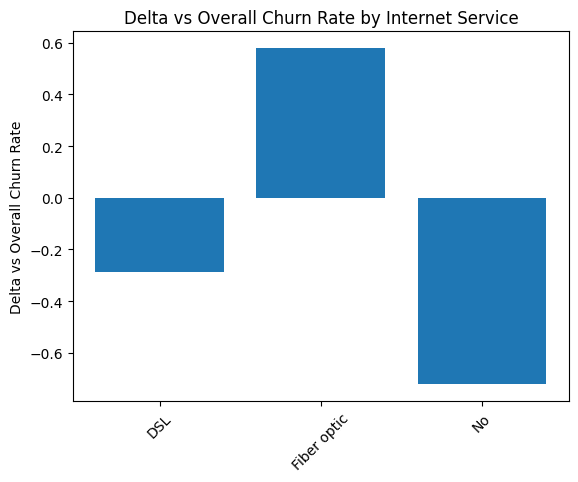

In [42]:
plt.bar(delta_vs_overall.index, delta_vs_overall['Churn'])
plt.xticks(rotation=45)
plt.ylabel('Delta vs Overall Churn Rate')
plt.title('Delta vs Overall Churn Rate by Internet Service')
plt.savefig(paths['churn rate graph'])
plt.show()